Always run this block first !

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import time
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
import os

# 6. Fairness Verification
**Goal:** Validate that the equilibrium allocation satisfies Proportionality and Envy-Freeness.

**Subplot a:** Proportionality Validation (Per-User)
* X-axis: User ID ($1 \dots 10$).
* Y-axis: Utility Value.
* *Success Criteria*: Every Blue Bar must extend above its corresponding Red Dash.

**Subplot b:** Pairwise Envy
* Type: Heatmap (10X10).
* Color: Diverging (Blue = Negative/Zero, Red = Positive).
* *Success Criteria*: Entire map is Blue/White. No Red.

In [2]:
# --- ENVY FREENESS METRICS ---
def calculate_ces_utility(allocation_vec, valuations_vec, m=1):
    """
    Calculates CES utility for a single user based on the formula:
    U_i(x_i) = (sum_j (v_ij * x_ij)^m)^(1/m)

    Parameters:
    - allocation_vec: (k,) array of allocated goods for one user
    - valuations_vec: (k,) array of valuation weights for one user
    - m: exponent parameter. Can be an integer/float or 'inf'.
      If m='inf', calculates U_i(x_i) = max_j (v_ij * x_ij)

    Returns:
    - Scalar utility value for the user.
    """
    # Element-wise product: value derived from each item
    # shape: (k,)
    product = valuations_vec * allocation_vec

    if m == 'inf':
        # Limit case: Max over items
        return np.max(product, axis=1)
    else:
        # Standard CES form
        # We handle potential negative values by taking abs, though in this context x and v are usually non-negative.
        sum_pow = np.sum(np.power(product, m), axis=1)
        return np.power(sum_pow, 1/m)

def envy_freeness_ces(allocation, valuations, m=1):
    """
    Checks Loose Envy Freeness condition using CES utility.
    User i envies User j if U_i(A_j) > U_i(A_i) + epsilon.

    Parameters:
    - allocation: (n, k) matrix of allocated goods
    - valuations: (n, k) matrix of linear valuations weights
    - m: exponent parameter for CES utility. Can be an integer/float or 'inf'.
    - epsilon: tolerance for envy check. U_i(A_j) > U_i(A_i) + epsilon.
    - return_relative_envy: If True, max_user_envy will be (Max_j U_i(A_j) - U_i(A_i)) / U_i(A_i).
                            Otherwise, it returns the absolute difference.

    Returns:
    - satisfaction_pct: Percentage of users who do not envy anyone (max_envy <= epsilon)
    - max_user_envy: List of max envy values for each user.
                     If return_relative_envy is True, Value = (Max_j U_i(A_j) - U_i(A_i)) / U_i(A_i)
                     Else, Value = (Max_j U_i(A_j) - U_i(A_i))
    """
    n = len(allocation)

    # Calculate utilities of each user for their own bundle
    u_own = calculate_ces_utility(allocation, valuations, m)
    user_envy_data = []

    for i in range(n):
        # Calculate utility of user i for EVERYONE's bundle
        # We tile user i's valuation to match the shape of allocation matrix
        val_i_matrix = np.tile(valuations[i], (n, 1))
        u_i_all = calculate_ces_utility(allocation, val_i_matrix, m)

        # Calculate difference: U_i(A_j) - U_i(A_i) (shape (10, 1) - scalar)
        envy_values = u_i_all - u_own[i]
        user_envy_data.append(envy_values)

    # Create Dataframe
    df = pd.DataFrame(user_envy_data, index=np.arange(1, n+1, 1), columns=np.arange(1, n+1, 1))
    df.index.name = 'User_I (Evaluatee)'
    df.columns.name = 'User_J (Evaluator)'

    return df

# ENVY HEATMAP
def create_heatmap(df, title):
  df = df.sort_index(ascending=False)
  plt.figure(figsize=(8, 6))
  if df.shape[0] > 20:
    plt.figure(figsize=(30, 20))
  obj = sns.heatmap(df, cmap='coolwarm', center=0,
              square=True, annot=True, fmt='.2f')
  plt.title(f"Pairwise Envy Heatmap {(title)}")
  plt.xlabel('User_I (Evaluatee)')
  plt.ylabel('User_J (Evaluator)')

In [3]:
# --- FAIR UTILITY WITH VALUATIONS ---
def calc_fair_utility(allocation, valuations, budgets):
    """
    Fair Utility = (B_i / Total_Budget) * U_i(Total_Resources)
    """
    n_users = allocation.shape[0]
    total_budget = np.sum(budgets)
    print(f"Total Budgets: {total_budget}")
    total_resources = np.sum(allocation, axis=0)
    print(f"Total Resources: {total_resources}")

    fair_utilities = []
    for i in range(n_users):
        # Calculate U_i(Total_Resources) for each user
        total_bundle = total_resources.reshape(1, -1)
        val_i_reshaped = valuations[i].reshape(1, -1)
        u_i_all_goods = calculate_ces_utility(total_bundle, val_i_reshaped)[0]

        # Proportional share required
        required_share = (budgets[i] / total_budget) * u_i_all_goods
        fair_utilities.append(required_share)


    return fair_utilities

def proportionality_comparison(sgd_util, solver_util, sgd_baseline, solver_baseline,
                                    label_a='SPDS', label_b='CVXPY'):
    """
    Draws a horizontal comparison of utility differences from fair utility.
    Matches the overlapping filled/outlined bar style of the reference image.
    """

    # 1. Calculate the differences (Actual - Fair)
    diff_a = (sgd_util - sgd_baseline).flatten()
    diff_b = (solver_util - solver_baseline).flatten()

    n_users = len(diff_a)
    user_ids = [f"User {i+1}" for i in range(n_users)]

    # Reverse order so User 1 is at the top
    user_ids.reverse()
    diff_a = diff_a[::-1]
    diff_b = diff_b[::-1]

    # 2. Setup Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = np.arange(n_users)
    bar_height = 0.6

    # 3. Draw Model A (SPDS) - Filled Bars (Peach/Orange color)
    ax.barh(y_pos, diff_a, height=bar_height,
            color='#fddbc7', label=label_a, align='center', zorder=2)

    # 4. Draw Model B (CVXPY) - Outlined Bars
    ax.barh(y_pos, diff_b, height=bar_height,
            edgecolor='black', fill=False, linewidth=2,
            label=label_b, align='center', zorder=3)

    # 5. Annotations (Upper edge of the horizontal bar)
    for i, (val_a, val_b) in enumerate(zip(diff_a, diff_b)):
        # Adjusting text position to be just above the bar
        ax.text(val_a, i + 0.4, f'{val_a:.3f}',
                va='center', ha='center', fontsize=9, color='#d95f02')
        ax.text(val_b, i - 0.4, f'{val_b:.3f}',
                va='center', ha='center', fontsize=9, color='black')

    # 6. Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(user_ids)
    ax.axvline(0, color='black', linewidth=1.2, zorder=4) # Central axis

    # Grid and Spines
    ax.grid(axis='x', linestyle='-', alpha=0.7, zorder=1)
    ax.set_title(f"Proportionality Gap: {label_a} vs {label_b} ({n_users} Users)")
    ax.set_xlabel("Utility Difference (Actual - Fair Share)")

    # Legend placement similar to reference image
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    return fig

## 10 users and 24 items

In [7]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"

# Import valuations
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(120, 12) + 0.5         # 120 buyers, 12 goods

✓ Đã tải xong factors. Ma trận Valuations có shape: (10, 24)


Total Budgets: 100
Total Resources: [8.64371237e+00 8.68668950e+00 2.44361598e+00 7.00107620e+00
 9.01377731e+00 6.82165095e-04 2.98129063e+00 5.61005658e-04
 5.61201738e-04 9.55596074e-04 2.00087808e+01 5.61480121e-04
 1.92387085e+00 1.23831277e+01 1.20599730e-03 3.76538798e+00
 1.22518081e+01 6.82165095e-04 5.61673887e-04 1.20661609e-03
 5.61101349e-04 1.16194470e+01 1.20599730e-03 1.20661609e-03]
Total Budgets: 100
Total Resources: [8.85652686e+00 5.10375969e+00 8.16050955e+00 8.74398184e+00
 7.49122183e+00 8.12322662e-01 5.99029438e+00 8.80258451e+00
 1.84053349e-04 5.44169901e+00 8.42658977e+00 1.13647685e+00
 3.96304964e+00 7.56096125e+00 2.65126157e-07 8.06252379e+00
 6.92593111e+00 8.21488118e-01 3.44130743e-04 2.65056087e-07
 2.36530153e-04 5.71085018e+00 2.65124834e-07 2.65054060e-07]
Supply: [8.85660322 5.10375975 8.16824117 8.74401941 7.49253506 6.12398323
 5.99031432 8.80265356 5.84555418 5.44169907 8.42679909 9.76696673
 5.01974133 7.56096132 9.06310481 8.06263033 8.60877

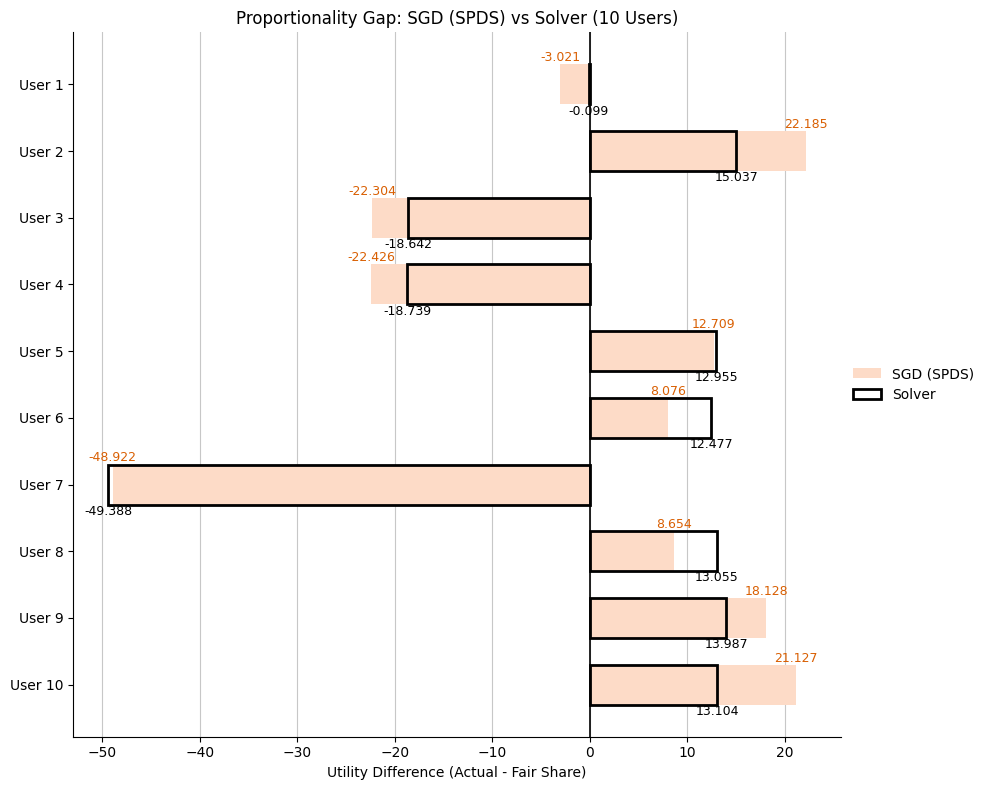

In [12]:
# Load data
file_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_10u_24i.pkl"
solver_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_10u_24i.pkl"
with open(file_path, "rb") as f:
    data = pickle.load(f)

with open(solver_path, "rb") as s:
    df = pickle.load(s)

sgd_util = calculate_ces_utility(data["alloc_final"][-1], valuations)
solver_util = calculate_ces_utility(df["solver_alloc"], valuations)
sgd_baseline = calc_fair_utility(data["alloc_final"][-1], valuations, data["data"]["budgets"])
solver_baseline = calc_fair_utility(df["solver_alloc"], valuations, df["config"]["budgets"])
print(f"Supply: {data['data']['supply_s']}")
print(f"Supply: {df['config']['supply_s']}")

# PROPORTIONAL COMPARISON
fig1 = proportionality_comparison(
    sgd_util,
    solver_util,
    sgd_baseline,
    solver_baseline,
    label_a='SGD (SPDS)',
    label_b='Solver'
)

# Save and Show
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/fairness/proportional_comparison.png", bbox_inches='tight', dpi=300)
plt.show()

In [22]:
path = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_200u_240i.pkl"
with open(path, "rb") as f:
    data = pickle.load(f)
    print(data["objective"])

[None, np.float64(5297.4763814506505)]


[None, np.float64(497.14751616003815)]
598.5398515789351
Capacity: [[2.32549952 2.30204198 2.85330094 2.53941473]
 [2.95119155 2.80311686 3.41566959 2.56494146]
 [3.72594664 1.95770827 1.27137805 1.90210017]
 [1.34195309 3.48604398 1.14068896 2.87886144]
 [2.64275847 3.45786099 1.59684262 3.57055091]
 [2.05495792 3.26394307 1.88788512 3.65180944]
 [1.97653491 1.49504769 2.17758773 1.28038112]
 [3.46331697 1.45345606 2.15234335 3.83278214]
 [3.96287642 2.36891364 3.47836853 1.7541224 ]
 [2.79211494 3.70849528 2.60367385 2.77060409]]


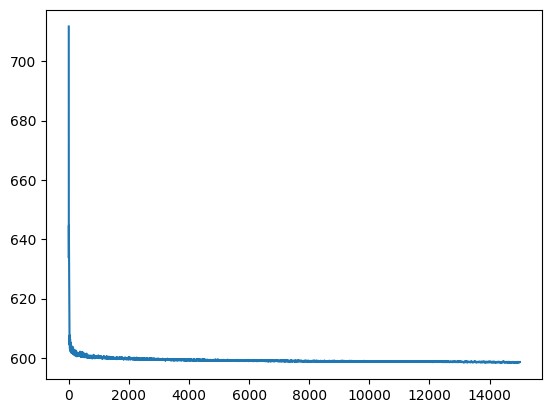

In [9]:
print(df["objective"])
print(data['objective'][-1])
print(f"Capacity: {data["data"]["capacity_b"]}")
plt.plot(data['objective'])

User_J (Evaluator)         1          2          3          4          5   \
User_I (Evaluatee)                                                          
1                    0.000000  17.587081 -11.645174 -11.787127  12.711854   
2                  -26.885937   0.000000 -44.435126 -44.675063  -7.452052   
3                   17.593466  44.547343   0.000000  -0.237771  37.075071   
4                   17.740034  44.551738   0.241789   0.000000  37.117889   
5                  -16.772356   6.324361 -31.797086 -31.971006   0.000000   
6                  -12.620196  13.271281 -29.453429 -29.697591   6.086837   
7                   44.195782  71.226223  26.554373  26.314398  63.731604   
8                  -13.149284  12.559393 -29.908676 -30.136514   5.453441   
9                  -22.472728   2.411746 -38.756071 -38.953294  -4.471477   
10                 -25.228360  -1.946766 -40.337679 -40.582818  -8.427826   

User_J (Evaluator)         6          7          8          9          10  

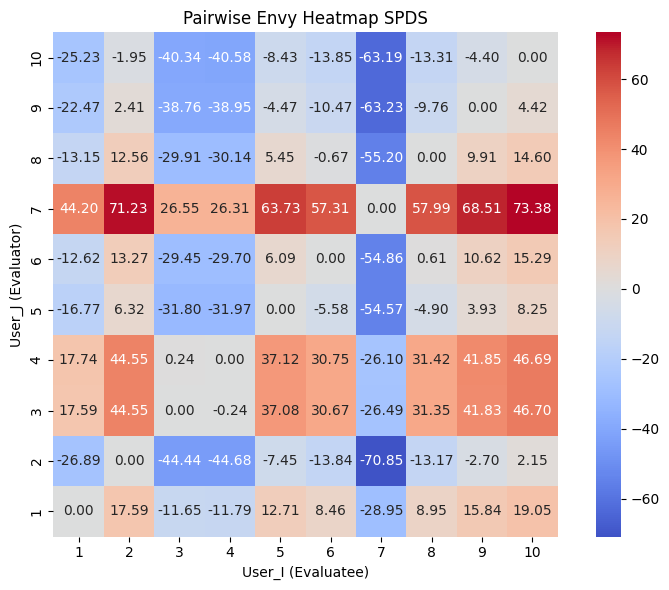

In [10]:
# ENVY METRICS
envy_metrics_sgd = envy_freeness_ces(data["alloc_final"][-1], valuations, m=1)
print(envy_metrics_sgd)

# ENVY FAIRNESS SPDS
create_heatmap(envy_metrics_sgd, "SPDS")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/fairness/envy_heatmap_spds.png")
plt.tight_layout()
plt.show()

User_J (Evaluator)         1          2          3          4          5   \
User_I (Evaluatee)                                                          
1                    0.000000   9.972568 -12.140389 -12.268864   9.941312   
2                  -15.290051   0.000000 -33.631245 -33.827713  -0.058923   
3                   18.385523  33.717959   0.000000  -0.203732  33.662749   
4                   18.486172  33.730374   0.196989   0.000000  33.672573   
5                  -13.202616  -0.031847 -28.915342 -29.161839   0.000000   
6                  -12.731007   1.980089 -30.350324 -30.543767   1.913874   
7                   49.131692  64.502699  30.693603  30.495819  64.446670   
8                  -13.305347   1.324259 -30.830139 -31.050664   1.294974   
9                  -14.222638  -0.087457 -31.230752 -31.383032  -0.066681   
10                 -13.353157  -0.113877 -29.170075 -29.365787  -0.161168   

User_J (Evaluator)         6          7          8          9          10  

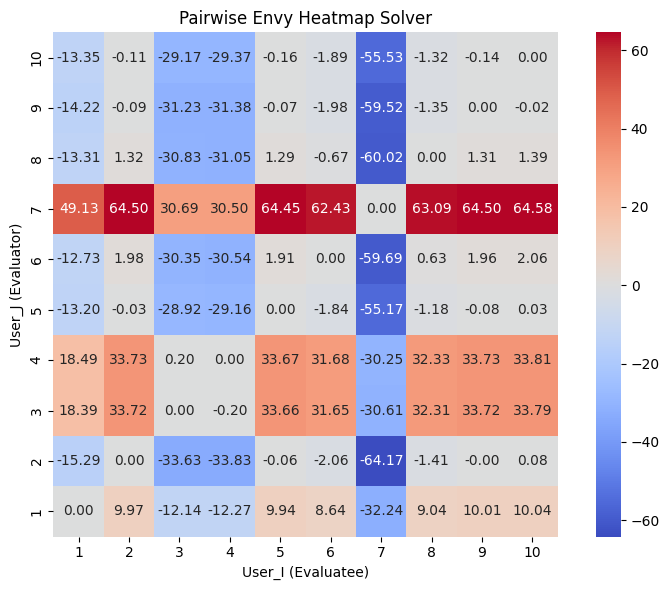

In [11]:
envy_metrics_solver = envy_freeness_ces(df["solver_alloc"], valuations, m=1)
print(envy_metrics_solver)

# ENVY FAIRNESS SOLVER
create_heatmap(envy_metrics_solver, "Solver")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/fairness/envy_heatmap_solver.png")
plt.tight_layout()
plt.show()

##

# 4. Efficiency (Not Run)
**Goal:** Show that the stochastic approach (SPDS) minimizes error much faster in terms of wall-clock time compared to the deterministic approach (DPDS) and centralized solver. Also the Stochastic (SPDS) method provides a "good enough" (e.g., 99% accurate) solution much earlier than Centralized Solver.
* X-axis: Wall-Clock Time (seconds).
* Y-axis: Relative Error (Log Scale).

**Description:** This plot demonstrates the time efficiency of the stochastic method.
* SPDS (Red Dashed): Extremely fast initial error reduction, dropping vertically in the first second.
* DPDS (Blue Solid): Slower, smoother error reduction, but eventually reaching a lower error than the stochastic noise floor.
* Centralized Solver (Black Dotted "Step"): Stays at high error (flat) for a setup period, then drops vertically to near-zero error.



In [6]:
def efficiency_graph(
        spds_obj_hist, dpds_obj_hist,
        solver_obj, spds_overall_time,
        dpds_iter_time, solver_time, solver_iters):
    """
    Draw time-based convergence efficiency graph.

    Parameters:
      - spds_obj_hist: SPDS objective history (log_freq = 10).
      - dpds_obj_hist: DPDS objective history (log_freq = 10).
      - solver_obj: Centralized solver objective ([start, end])
      - spds_overall_time: SPDS iteration times.
      - dpds_iter_time: DPDS iteration times.
      - solver_time: Centralized solver times.
      - solver_iter (int): Centralized solver iterations.
    """

    # --- Adjust time for each iterations (DPDS) and each user (SPDS is parallel) ---
    spds_time = np.array([spds_overall_time/len(spds_obj_hist)] * len(spds_obj_hist))
    dpds_time = np.array(dpds_iter_time)

    plt.figure(figsize=(10, 6))
    # SPDS line
    plt.plot(spds_time, spds_obj_hist, 'r--', linewidth=2, label="SPDS (Stochastic)")
    # DPDS line
    plt.plot(dpds_time, dpds_obj_hist, 'b-', linewidth=2, label="DPDS (Deterministic)")

    # SOLVER VISUALISATION
    time_arr = np.array([0, solver_time])
    # Create a range for visualization including before and after
    x = np.linspace(-1, solver_time + 1, 500)
    piecewise_obj = np.piecewise(x,
                 [x < time_arr[0],
                  (x >= time_arr[0]) & (x <= time_arr[1]),
                  x > time_arr[1]],
                 [lambda x: solver_obj[0],
                  lambda x: solver_obj[0] + (solver_obj[1] - solver_obj[0]) * (x - time_arr[0]) / (time_arr[1] - time_arr[0]),
                  lambda x: solver_obj[1]])
    plt.plot(time_arr, solver_obj, 'k:', linewidth=2.5, label="Centralized Solver")

    # ---------- Formatting ----------
    plt.xlabel("Wall-Clock Time (s)", fontsize=14)
    plt.ylabel("Objective Value", fontsize=14)
    plt.title("Convergence Efficiency (Time-Based)", fontsize=15)

    plt.grid(True, which="both", linestyle="--", linewidth=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()

## 50 users 60 items

In [20]:
print(solver_obj)
print(solver_time)
print(solver_iterations)

[0, np.float64(1476.0403653580597)]
0.458458986999176
18


In [18]:
print(dpds_obj_hist)
print(dpds_iter_time)

[np.float64(14817.340282998493), np.float64(15742.930858294407), np.float64(16664.273946234895), np.float64(17653.4884418483), np.float64(18400.150538489383), np.float64(18529.158704485464), np.float64(19749.325202995857), np.float64(19967.498671363603), np.float64(20667.267806637363), np.float64(21189.948696606793), np.float64(21811.75941729368), np.float64(21991.5265258031), np.float64(23173.60682820831), np.float64(23469.7093400565), np.float64(24083.5828742076), np.float64(24200.257325793733), np.float64(24848.067322890707), np.float64(25179.17399814356), np.float64(25491.0897085159), np.float64(25684.97731518025), np.float64(25948.80743087657), np.float64(26616.787630998973), np.float64(26589.414661095336), np.float64(27428.002075705037), np.float64(27843.48128018411), np.float64(28114.194865724803), np.float64(28274.278538184022), np.float64(28612.762111228192), np.float64(28856.78653310152), np.float64(29422.79416429513), np.float64(29890.387139820752), np.float64(29796.12500336

In [19]:
print(spds_obj_hist)
print(spds_overall_time)

[np.float64(4219.091950438392), np.float64(4334.656776124421), np.float64(4604.328048353575), np.float64(4834.930059299064), np.float64(4982.736366375717), np.float64(5117.983903482565), np.float64(5270.697301743272), np.float64(5419.540123651801), np.float64(5547.492361782745), np.float64(5690.447477130343), np.float64(5812.211879310886), np.float64(5882.198951492435), np.float64(5954.087751124886), np.float64(6022.00836308874), np.float64(6046.143458901757), np.float64(6035.841126264848), np.float64(6048.057139873622), np.float64(6020.1612891367495), np.float64(6004.996351358563), np.float64(5979.938534940946), np.float64(5944.162316303762), np.float64(5869.095902591145), np.float64(5814.654908274327), np.float64(5780.591220123617), np.float64(5754.236414140372), np.float64(5714.132735134375), np.float64(5662.579408655714), np.float64(5607.016761838071), np.float64(5577.911250693513), np.float64(5545.203940384021), np.float64(5506.336948657027), np.float64(5463.065089113114), np.floa

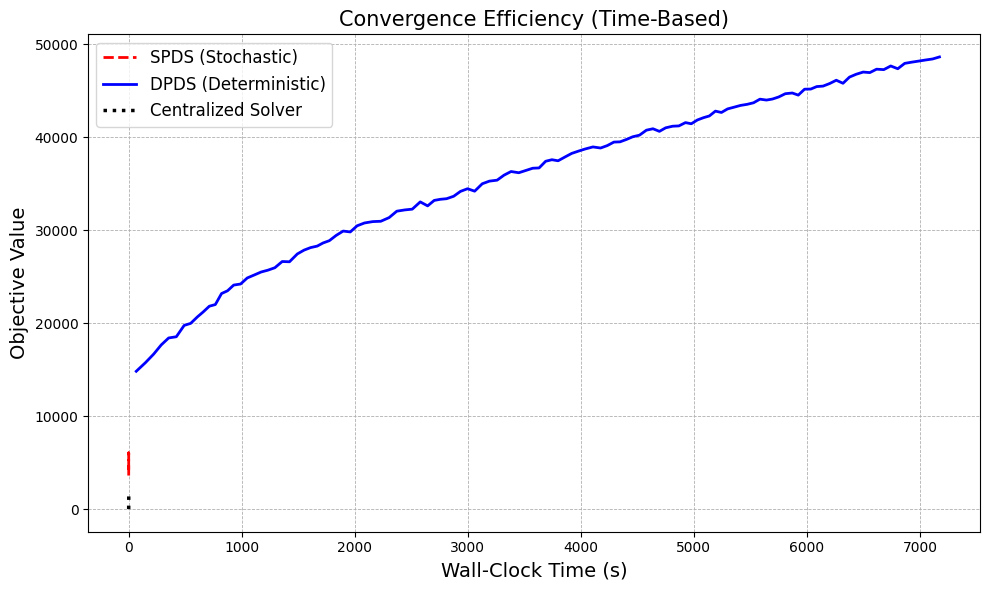

In [7]:
file_path_spds = "/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_50u_60i.pkl"
file_path_dpds = "/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_50u_60i.pkl"
file_path_solver = "/content/drive/MyDrive/EV_charging_project/experiment_result/cvxpy_results_50u_60i.pkl"

with open(file_path_spds, "rb") as f:
    spds = pickle.load(f)
    spds_overall_time, spds_obj_hist,  = spds["total_time"], spds["objective"]
with open(file_path_dpds, "rb") as f:
    dpds = pickle.load(f)
    dpds_iter_time, dpds_obj_hist = dpds["time_log"], dpds["obj_hist"]
with open(file_path_solver, "rb") as f:
    solver = pickle.load(f)
    solver_obj, solver_time, solver_iterations = solver["objective"], solver["t_solver"], solver["iterations"]
    solver_obj[0] = 0

# Visualization
efficiency_graph(spds_obj_hist, dpds_obj_hist, solver_obj,
                 spds_overall_time, dpds_iter_time, solver_time, solver_iterations)
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/efficiency_graph_50u_60i.png")
plt.show()

## 200 users 240 items

In [16]:
file_path_spds = "/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_200u_240i.pkl"
file_path_dpds = "/content/drive/MyDrive/EV_charging_project/experiment_result/dpds_results_200u_240i.pkl"
file_path_solver = "/content/drive/MyDrive/EV_charging_project/experiment_result/solver_results_200u_240i.pkl"

with open(file_path_spds, "rb") as f:
    spds = pickle.load(f)
    spds_obj_hist, spds_iter_time = spds["time_log"], spds["objective"]
with open(file_path_dpds, "rb") as f:
    dpds = pickle.load(f)
    dpds_obj_hist, dpds_iter_time = dpds["time_log"], dpds["objective"]
with open(file_path_solver, "rb") as f:
    solver = pickle.load(f)
    solver_obj, solver_time, solver_iterations = solver["objective"], solver["t_solver"], solver["iterations"]

# Visualization
efficiency_graph(spds_obj_hist, dpds_obj_hist, solver_obj,
                 spds_iter_time, dpds_iter_time, solver_time, solver_iters)
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/efficiency_graph_200u_240i.png")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_200u_240i.pkl'

#

# 5. System Scalability (Not Run)
**Goal:** Demonstrate the algorithm's versatility across different utility functions and its superior scaling compared to centralized solvers.
* X-axis: Number of Users (N) (Log Scale).
* Y-axis: Time to Converge (s) (Log Scale).
* Description: Compares the computational scaling.
* Centralized Solver (Black Squares): Shows a steep, cubic scaling slope $O(N^3)$.
* Distributed SPDS (Blue Circles): Shows a much shallower, linear scaling slope $O(N)$, demonstrating superior scalability.

In [19]:
import re

def extract_users(key):
    """Extract number of users (integer before 'u') from keys like '50u_60i'."""
    return int(re.match(r"(\d+)u", key).group(1))

def scalability_graph(users_arr, solver_time_arr, spds_time_arr):
    """
    Parameters:
      - users_arr: Array of number of users.
        e.g. [10, 50, 200, 300, 400, 500]
      - solver_time_arr: Array of solver times.
        CVXPY running time w.r.t number of users
      - spds_time_arr: Array of SPDS times.
        SPDS running time w.r.t number of users

    """
    plt.figure(figsize=(8, 6))
    plt.plot(users_arr, solver_time_arr, '-s', markersize=8, linewidth=2, label="Centralized Solver")
    plt.plot(users_arr, spds_time_arr, '-o', markersize=8, linewidth=2, label="Distributed SPDS")
    plt.xticks(users_arr)
    plt.xlabel("Number of Agents (N)", fontsize=13)
    plt.ylabel("Time to Converge (s)", fontsize=13)
    plt.title("System Scalability", fontsize=14)
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)
    plt.legend(fontsize=12)
    plt.tight_layout()

[0, 2328.41006293, 2011.6348821659994, 9622.819900034, 156.57299889499882, 473.5518009810021]


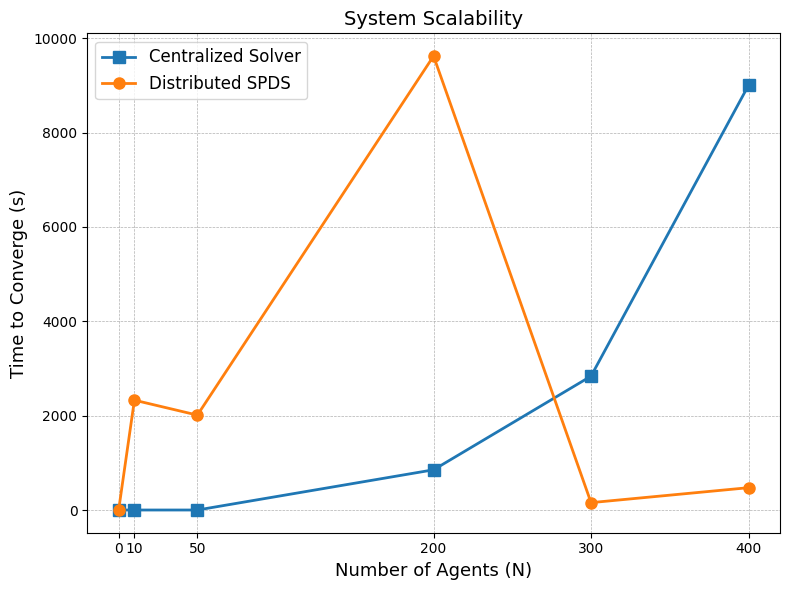

In [21]:
path_spds = "/content/drive/MyDrive/EV_charging_project/experiment_result"
path_solver = "/content/drive/MyDrive/EV_charging_project/experiment_result"
keys = ["10u_24i", "50u_60i", "200u_240i", "300u_360i", "400u_480i"]

# Initialize for both algorithms
extracted_users = pd.Series(keys).str.extract(r"(\d+)u")[0].astype(int).tolist()

# Initialize for both algorithms
users_arr = [0] + extracted_users
solver_time_arr = [0]
spds_time_arr = [0]

for k in keys:
    with open(f"{path_spds}/spds_results_{k}.pkl", "rb") as f:
        spds = pickle.load(f)
        spds_time_arr.append(spds["total_time"])

    with open(f"{path_solver}/cvxpy_results_{k}.pkl", "rb") as f:
        solver = pickle.load(f)
        solver_time_arr.append(solver["t_solver"])

print(spds_time_arr)

# VISUALIZATION
scalability_graph(users_arr, solver_time_arr, spds_time_arr)
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/system_scalability.png")
plt.show()

In [23]:
 with open("/content/drive/MyDrive/EV_charging_project/experiment_result/spds_results_200u_240i.pkl", "rb") as f:
    spds = pickle.load(f)
    total_time = spds["total_time"]
    spds_user_time = spds["time_log"]

print(total_time)
print(spds_user_time)


9622.819900034
[1893.02892985 1867.03881233 1896.04297161 1893.44473219 1884.99846106
 1862.0407155  1867.66109497 1889.80136424 1862.85693248 1867.2985494
 1891.82836245 1910.5896203  1859.52508037 1876.17763616 1890.94862289
 1886.96924714 1886.41612576 1868.49184146 1904.22389034 1893.68873925
 1879.50269585 1863.26848151 1880.24148804 1890.79865588 1874.79560044
 1875.04895647 1880.18904447 1883.72094    1890.11976472 1881.09157797
 1895.92308748 1873.14276219 1905.64487718 1871.68148933 1863.15625921
 1872.45157634 1863.12028309 1894.91811557 1861.29086631 1885.85008781
 1876.96627904 1890.58969014 1862.4675927  1889.28914363 1867.99003819
 1883.65405819 1864.52341979 1896.09492752 1864.98486737 1867.0360987
 1868.37135926 1863.31458145 1894.902735   1864.00622969 1870.46672293
 1899.72731597 1905.74634182 1878.14492678 1889.33923572 1864.95926943
 1881.83769804 1891.93247222 1880.45749783 1879.79770312 1861.06250611
 1871.24815516 1864.93233015 1869.86793457 1873.98087273 1884.37